In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target_original'] = data.target
# 0, 1 뒤집어서 malignant 를 1로 바꿈. 
df['target'] = 1 - df['target_original']

df['target_name'] = df['target'].map({
    0: 'benign',
    1: 'malignant'
})

df.shape

(569, 33)

In [3]:
df[['target_original', 'target', 'target_name']].head()

,target_original,target,target_name
0,0,1,malignant
1,0,1,malignant
2,0,1,malignant
3,0,1,malignant
4,0,1,malignant


In [4]:
df['target_name'].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [5]:
# 입력정보 X. 정답과 관련된 컬럼 3개 제외
X = df.drop(columns=['target_original', 'target', 'target_name'])
# 정답 y. 만들어 놓은 target사용
y = df['target']
print('X의 열 개수:', X.shape[1])
print('정답 관련 컬럼이 X에 있나요?',
      any(col in X.columns for col in ['target_original', 'target', 'target_name']))

X의 열 개수: 30
정답 관련 컬럼이 X에 있나요? False


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('학습용 데이터 개수:', X_train.shape[0])
print('평가용 데이터 개수:', X_test.shape[0])

학습용 데이터 개수: 455
평가용 데이터 개수: 114


In [7]:
# 분류모델 만들기
model = XGBClassifier(
    random_state=42, # 결과 같게 만들기 위한 고정값
    eval_metric='logloss', # 경고 메시지 줄이기
    n_jobs=1 # cpu 코어 수 1개 고정
)

model.fit(X_train, y_train) # 학습
y_pred = model.predict(X_test) # 예측

y_pred_proba = model.predict_proba(X_test)[:, 1]

print('예측 완료! 예측한 데이터 개수:', len(y_pred))
print('예측값 예시 (앞 10개):', y_pred[:10])
print('malignant 확률 예시 (앞 5개):', y_pred_proba[:5].round(3))

예측 완료! 예측한 데이터 개수: 114
예측값 예시 (앞 10개): [0 1 0 1 0 0 1 0 0 0]
malignant 확률 예시 (앞 5개): [0.001 1.    0.04  0.993 0.017]


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print('accuracy:', accuracy)
print(f'즉, 전체의 약 {accuracy*100:.1f}% 를 맞혔습니다.')

accuracy: 0.9736842105263158
즉, 전체의 약 97.4% 를 맞혔습니다.


In [11]:
# 클래스 이름 순서 고정. 원본 뒤집기
class_names = ['benign', 'malignant']
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print(cm)

[[72  0]
 [ 3 39]]


Text(0.5, 1.0, 'Confusion Matrix')

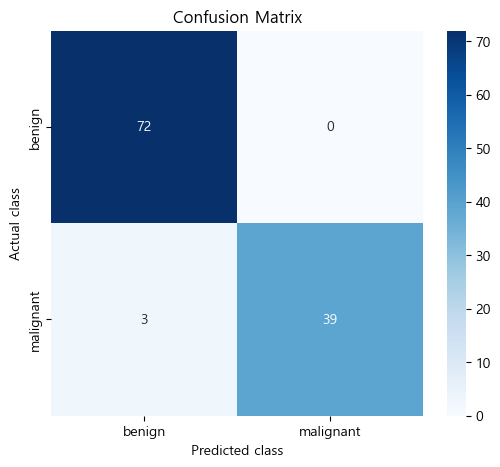

In [ ]:
plt.figure(figsize=(6, 5))
# 칸에 숫자 직접 표시, 정수형태
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names
)

plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Confusion Matrix')

In [ ]:
# 클래스별 precision, recall, f1-score 출력
print(
    classification_report(
        y_test, y_pred, labels=[0, 1], target_names=class_names
    )
)

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [14]:
X_test_reset =X_test.reset_index(drop=True).copy()
y_test_reset = y_test.reset_index(drop=True)

result_df = X_test_reset.copy()

result_df['y_true'] = y_test_reset
result_df['y_pred'] = y_pred

result_df['malignant_probability'] = y_pred_proba

result_df['y_true_name'] = result_df['y_true'].map({0: 'benign', 1: 'malignant'})
result_df['y_pred_name'] = result_df['y_pred'].map({0: 'benign', 1: 'malignant'})

result_df['is_correct'] = result_df['y_true'] == result_df['y_pred']
result_df[['y_true', 'y_pred', 'y_true_name', 'y_pred_name', 'malignant_probability', 'is_correct']].head()

,y_true,y_pred,y_true_name,y_pred_name,malignant_probability,is_correct
0,0,0,benign,benign,0.001136,True
1,1,1,malignant,malignant,0.999783,True
2,0,0,benign,benign,0.039927,True
3,1,1,malignant,malignant,0.993436,True
4,0,0,benign,benign,0.016957,True


In [26]:
# 틀린데이터 고르기
wrong_df = result_df[result_df['is_correct'] == False]

print('틀린 예측 개수:', len(wrong_df))

if len(wrong_df) == 0:
    print('이번 test split에서는 틀린 예측이 발생하지 않았습니다.')
else:
    # 보고싶은 컬럼 목록
    important_columns = [
        'y_true_name',
        'y_pred_name',
        'malignant_probability',
        'mean radius',
        'mean perimeter',
        'mean area',
        'worst radius',
        'worst perimeter',
        'worst area',
        'worst concave points'
    ]

    available_columns = [col for col in important_columns if col in wrong_df.columns]
    display(wrong_df[available_columns].round(3))

틀린 예측 개수: 3


,y_true_name,y_pred_name,malignant_probability,mean radius,mean perimeter,mean area,worst radius,worst perimeter,worst area,worst concave points
16,malignant,benign,0.003,13.80,90.43,584.1,16.57,110.3,812.4,0.138
69,malignant,benign,0.377,12.45,82.57,477.1,15.47,103.4,741.6,0.174
112,malignant,benign,0.261,15.12,98.78,716.6,17.77,117.7,989.5,0.125


In [28]:
false_negative_df = result_df[(result_df['y_true'] == 1) & (result_df['y_pred'] == 0)]
print('False Negative 개수:', len(false_negative_df))

if len(false_negative_df) == 0:
    print('이번 test split에서는 false negative가 발생하지 않았습니다.')
else:
    display(false_negative_df[['y_true_name', 'y_pred_name']])

False Negative 개수: 3


,y_true_name,y_pred_name
16,malignant,benign
69,malignant,benign
112,malignant,benign


In [30]:
false_positive_df = result_df[(result_df['y_true'] == 0) & (result_df['y_pred'] == 1)]
print('False Positive 개수:', len(false_positive_df))

if len(false_positive_df) == 0:
    print('이번 test split에서는 false positive가 발생하지 않았습니다.')
else:
    display(false_positive_df[['y_true_name', 'y_pred_name']])

False Positive 개수: 0
이번 test split에서는 false positive가 발생하지 않았습니다.


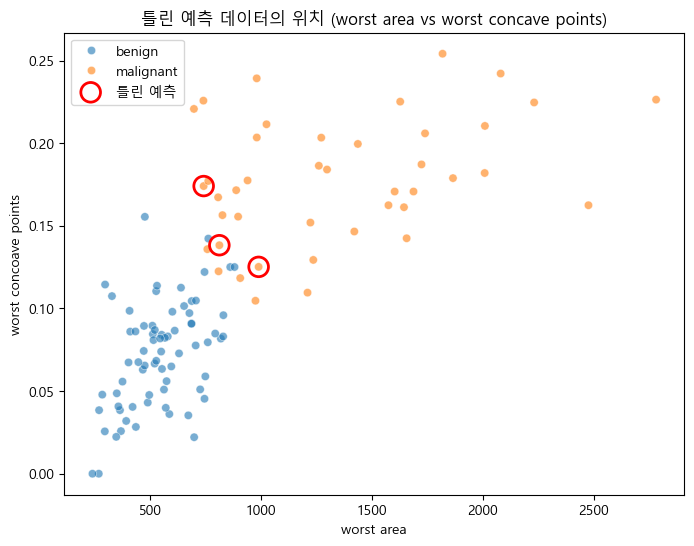

In [31]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=result_df,
    x='worst area',
    y='worst concave points',
    hue='y_true_name',
    alpha=0.6
)

if len(wrong_df) > 0:
    plt.scatter(
        wrong_df['worst area'],
        wrong_df['worst concave points'],
        s=200,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        label='틀린 예측'
    )
else:
    print('이번 test split에서는 틀린 예측이 없어 별도로 표시할 점이 없습니다.')

plt.title('틀린 예측 데이터의 위치 (worst area vs worst concave points)')
plt.xlabel('worst area')
plt.ylabel('worst concoave points')
plt.legend()


In [32]:
from sklearn.preprocessing import StandardScaler # feature들의 스케일을 맞춰줌
from sklearn.decomposition import PCA # 주성분

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=2) # 2개의 축으로 요약.

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('PCA변환 후 학습용 데이터 shape:', X_train_pca.shape)
print('PCA변환 후 평가용 데이터 shape:', X_test_pca.shape)

# 원래 데이터의 정보를 얼마나 담고있는지 비율 
print('PC1 설명 분산 비율:', round(pca.explained_variance_ratio_[0], 3))
print('PC2 설명 분산 비율:', round(pca.explained_variance_ratio_[1], 3))
print('PC1 + PC2 설명 분산 비율:', round(pca.explained_variance_ratio_.sum(), 3))

PCA변환 후 학습용 데이터 shape: (455, 2)
PCA변환 후 평가용 데이터 shape: (114, 2)
PC1 설명 분산 비율: 0.446
PC2 설명 분산 비율: 0.185
PC1 + PC2 설명 분산 비율: 0.631


In [33]:
# PCA결과 정리
pca_df = pd.DataFrame({
    'PC1': X_test_pca[:, 0], # 첫번째 축
    'PC2': X_test_pca[:, 1], # 두번째 축
    'y_true': y_test.values, # 실제 정답
    'y_pred': y_pred,        # 모델 예측
    'malignant_probability': y_pred_proba # 모델이 계산한 malignant 확률
})

# 이름 컬럼 추가
pca_df['y_true_name'] = pca_df['y_true'].map({
    0: 'benign', 1: 'malignant'
})

pca_df['y_pred_name'] = pca_df['y_pred'].map({
    0: 'benign', 1: 'malignant'
})

pca_df['is_correct'] = pca_df['y_true'] == pca_df['y_pred']

pca_df.head()

,PC1,PC2,y_true,y_pred,malignant_probability,y_true_name,y_pred_name,is_correct
0,-2.954871,0.471308,0,0,0.001136,benign,benign,True
1,6.892485,-2.047321,1,1,0.999783,malignant,malignant,True
2,-0.125826,-0.058798,0,0,0.039927,benign,benign,True
3,0.586226,0.666002,1,1,0.993436,malignant,malignant,True
4,-1.868729,-1.530491,0,0,0.016957,benign,benign,True


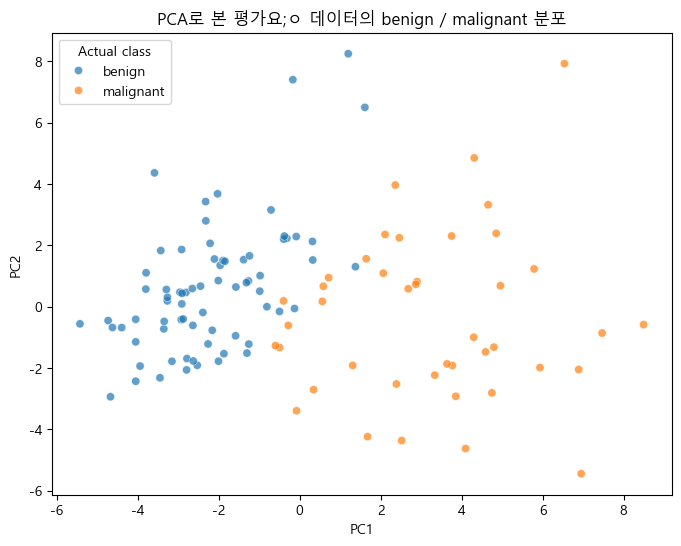

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='y_true_name',
    alpha=0.7
)

plt.title('PCA로 본 평가요;ㅇ 데이터의 benign / malignant 분포')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Actual class')

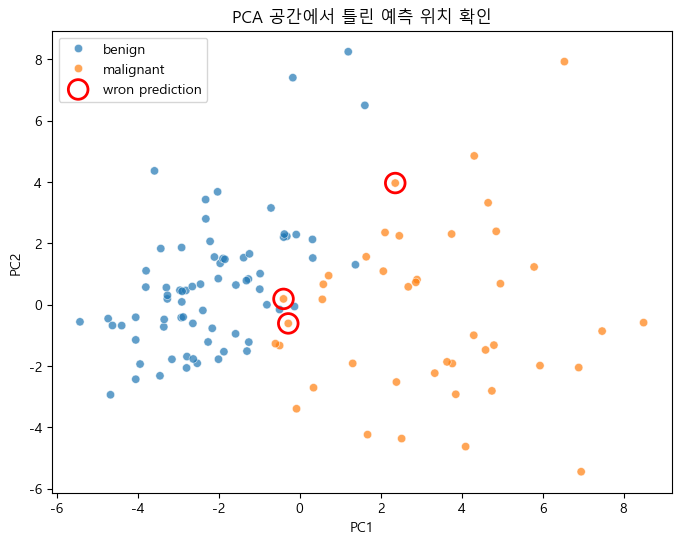

In [ ]:
plt.figure(figsize=(8, 6))
# 전체 평가용 데이터 그리기
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='y_true_name', alpha=0.7
)
# 틀린 예측만 골라내기
wrong_pca_df = pca_df[pca_df['is_correct'] == False]

# 빨간원 표시
if len(wrong_pca_df) > 0:
    plt.scatter(
        wrong_pca_df['PC1'],
        wrong_pca_df['PC2'],
        s=200,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        label='wron prediction'
    )

plt.title('PCA 공간에서 틀린 예측 위치 확인')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

In [37]:
# threshold 에따른 FN, FP 비교
from sklearn.metrics import confusion_matrix, classification_report
# threshold는 malignant라고 판단하는 기준값.
threshold_list = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]
for threshold in threshold_list:
    print('=' * 70)
    print(f'threshold = {threshold}')
    print('=' * 70)

    # malignant확률이 threshold 이상이면 1로 예측
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # confusion matrix 계산
    cm_threshold = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm_threshold,
        index=['Actual benign', 'Actual malignant'],
        columns=['Predicted benign', 'Predicted malignant']
    )

    print('\n[Confusion Matrix]')
    display(cm_df)

    # confusion matrix에서 FN, FP를 꺼냄
    fp = cm_threshold[0, 1]
    fn = cm_threshold[1, 0]

    print('\n[Classification Report]')
    print(
        classification_report(
            y_test,
            y_pred_threshold,
            labels=[0, 1],
            target_names=['benign', 'malignant'],
            zero_division=0
        )
    )
    print()

threshold = 0.5

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39



[Classification Report]
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.4

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39



[Classification Report]
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.3

[Confusion Matrix]


...


[Classification Report]
              precision    recall  f1-score   support

      benign       0.99      0.97      0.98        72
   malignant       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.01

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,61,11
Actual malignant,1,41



[Classification Report]
              precision    recall  f1-score   support

      benign       0.98      0.85      0.91        72
   malignant       0.79      0.98      0.87        42

    accuracy                           0.89       114
   macro avg       0.89      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114


threshold = 0.001

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,42,30
Actual malignant,0,42



[Classification Report]
              precision    recall  f1-score   support

      benign       1.00      0.58      0.74        72
   malignant       0.58      1.00      0.74        42

    accuracy                           0.74       114
   macro avg       0.79      0.79      0.74       114
weighted avg       0.85      0.74      0.74       114




threshold를 0.2해야 적절함

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

Text(0, 0.5, 'True Positive Rate Recall')

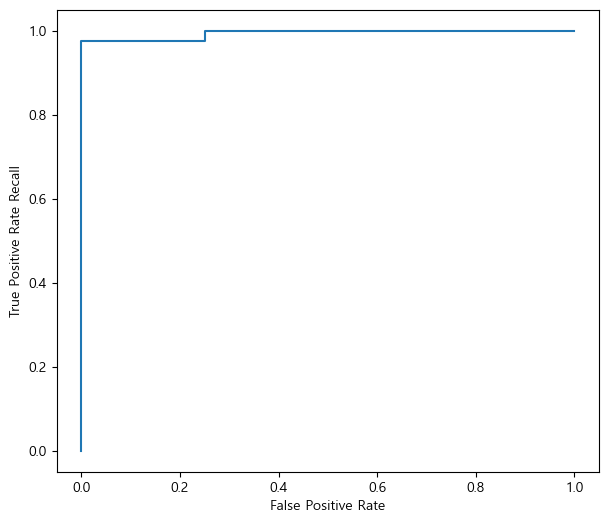

In [42]:
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate Recall')